### 1. Dataset summary (load and inspect)

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the datasets
users_df = pd.read_csv('data/users.csv')
events_df = pd.read_csv('data/events.csv')

# 2. Inspect Users Dataset
print("--- USERS DATASET SUMMARY ---")
print(f"Total Users: {users_df.shape[0]:,}")
print(f"Columns: {list(users_df.columns)}")
print(users_df.head(3))
# events dataset
print("\n--- EVENTS DATASET SUMMARY ---")
print(f"Total Events: {events_df.shape[0]:,}")
print(f"Columns: {list(events_df.columns)}")
print(events_df.head(3))

--- USERS DATASET SUMMARY ---
Total Users: 5,000
Columns: ['user_id', 'signup_date', 'company_size', 'acquisition_channel']
    user_id signup_date    company_size acquisition_channel
0  usr_1000  2025-09-01  Startup (1-10)            Paid Ads
1  usr_1001  2025-09-01  Startup (1-10)      Organic Search
2  usr_1002  2025-09-01  Startup (1-10)      Organic Search

--- EVENTS DATASET SUMMARY ---
Total Events: 145,650
Columns: ['event_id', 'user_id', 'timestamp', 'event_name']
     event_id   user_id                   timestamp           event_name
0  evt_200000  usr_1012  2025-09-01 00:34:48.146183     viewed_dashboard
1  evt_200001  usr_1013  2025-09-01 01:30:33.240420      created_project
2  evt_200002  usr_1014  2025-09-01 02:53:12.365737  invited_team_member


### 2. Data quality check

In [8]:
# 1. Check for missing values and duplicates in Users
print("--- USERS DATASET QUALITY ---")
print("Missing values:\n", users_df.isnull().sum())
print("Duplicate rows:", users_df.duplicated().sum())

# 2. Check for missing values and duplicates in Events
print("\n--- EVENTS DATASET QUALITY ---")
print("Missing values:\n", events_df.isnull().sum())
print("Duplicate rows:", events_df.duplicated().sum())

# 3. Check for data anomalies (Events happening before signup)
temp_merged = events_df.merge(users_df, on='user_id', how='inner')
temp_merged['signup_date'] = pd.to_datetime(temp_merged['signup_date'])
temp_merged['timestamp'] = pd.to_datetime(temp_merged['timestamp'])

anomalies = temp_merged[temp_merged['timestamp'] < temp_merged['signup_date']]
print(f"\nAnomaly Check: Events occurring BEFORE signup date = {len(anomalies):,} rows")

--- USERS DATASET QUALITY ---
Missing values:
 user_id                0
signup_date            0
company_size           0
acquisition_channel    0
dtype: int64
Duplicate rows: 0

--- EVENTS DATASET QUALITY ---
Missing values:
 event_id      0
user_id       0
timestamp     0
event_name    0
dtype: int64
Duplicate rows: 0

Anomaly Check: Events occurring BEFORE signup date = 0 rows


### 3. Data Cleaning

In [13]:
# Data Cleaning & Preprocessing

# 1. Ensure datetime types are correctly parsed
users_df['signup_date'] = pd.to_datetime(users_df['signup_date'])
events_df['timestamp'] = pd.to_datetime(events_df['timestamp'])

# 2. Merge users and events dataframes
df_clean = events_df.merge(users_df, on='user_id', how='inner')

# 3. Calculate days since signup to track user behavior over time
df_clean['days_since_signup'] = (df_clean['timestamp'] - df_clean['signup_date']).dt.days

# 4. Filter out any anomalous events occurring before signup (days_since_signup < 0)
initial_count = len(df_clean)
df_clean = df_clean[df_clean['days_since_signup'] >= 0]
filtered_count = initial_count - len(df_clean)

print(f"Data Cleaning Complete:")
print(f"• Removed {filtered_count:,} anomalous pre-signup event rows.")
print(f"• Final cleaned master dataset shape: {df_clean.shape}")
display(df_clean.head(3))

Data Cleaning Complete:
• Removed 0 anomalous pre-signup event rows.
• Final cleaned master dataset shape: (145650, 8)


,event_id,user_id,timestamp,event_name,signup_date,company_size,acquisition_channel,days_since_signup
0,evt_200000,usr_1012,2025-09-01 00:34:48.146183,viewed_dashboard,2025-09-01,Startup (1-10),Direct,0
1,evt_200001,usr_1013,2025-09-01 01:30:33.240420,created_project,2025-09-01,Startup (1-10),Paid Ads,0
2,evt_200002,usr_1014,2025-09-01 02:53:12.365737,invited_team_member,2025-09-01,Startup (1-10),Paid Ads,0



### 4. Exploratory Data Analysis and Visualization

C:\Users\Aman Suren\AppData\Local\Temp\ipykernel_10828\42430745.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=event_counts, x='count', y='event_name', ax=axes[2], palette='crest')


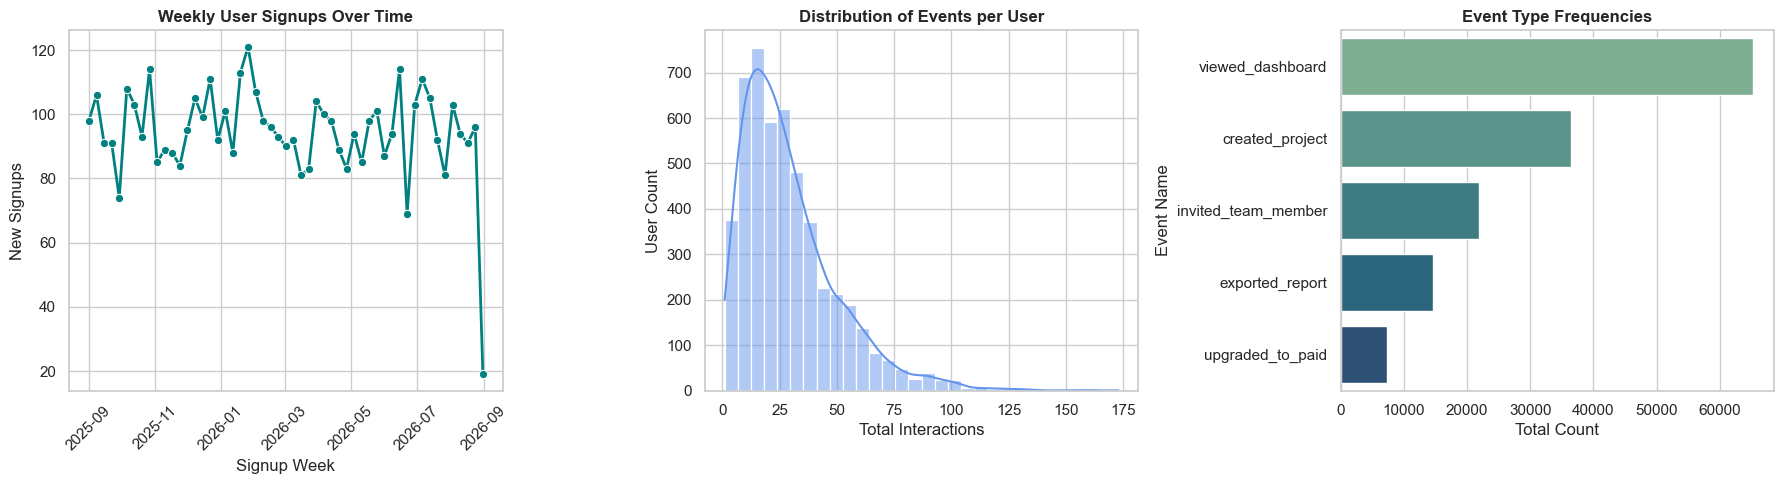

In [12]:
# Set visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Weekly User Signups Trend
users_df['signup_week'] = users_df['signup_date'].dt.to_period('W').dt.start_time
weekly_signups = users_df.groupby('signup_week')['user_id'].count().reset_index()
sns.lineplot(data=weekly_signups, x='signup_week', y='user_id', ax=axes[0], color='teal', marker='o', linewidth=2)
axes[0].set_title('Weekly User Signups Over Time', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Signup Week')
axes[0].set_ylabel('New Signups')
axes[0].tick_params(axis='x', rotation=45)

# 2. Distribution of Events per User
user_event_counts = df_clean.groupby('user_id')['event_id'].count()
sns.histplot(user_event_counts, bins=30, ax=axes[1], color='cornflowerblue', kde=True)
axes[1].set_title('Distribution of Events per User', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Interactions')
axes[1].set_ylabel('User Count')

# 3. Frequency of Event Types
event_counts = df_clean['event_name'].value_counts().reset_index()
event_counts.columns = ['event_name', 'count']
sns.barplot(data=event_counts, x='count', y='event_name', ax=axes[2], palette='crest')
axes[2].set_title('Event Type Frequencies', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Total Count')
axes[2].set_ylabel('Event Name')

plt.tight_layout()
plt.show()

### 5.Core data analysis (Cohort and Features)

--- CORE BUSINESS KPI ---
• Total Signups: 5,000
• Upgraded Users: 3,380
• Free-to-Paid Conversion Rate: 67.60%



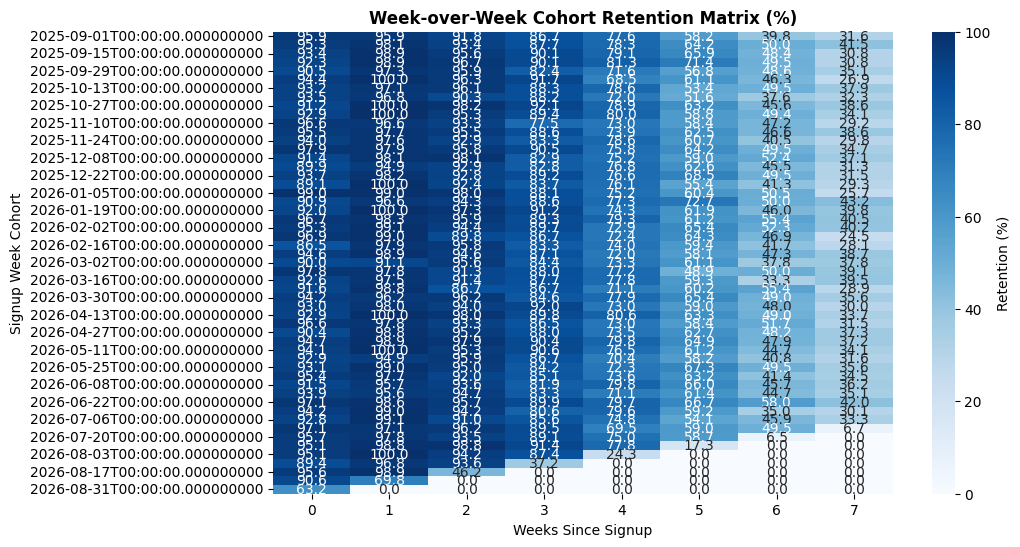


--- FEATURE CORRELATION WITH PAID UPGRADES ---
event_name
invited_team_member    0.239718
exported_report        0.196663
created_project        0.142474
viewed_dashboard       0.120219
Name: did_upgrade, dtype: float64


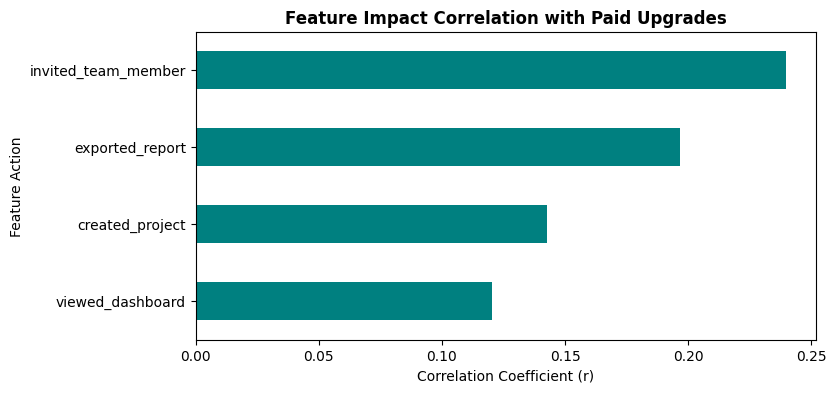

In [14]:


# 1. Overall Free-to-Paid Conversion Rate
total_users = users_df['user_id'].nunique()
upgraded_users = df_clean[df_clean['event_name'] == 'upgraded_to_paid']['user_id'].nunique()
conversion_rate = (upgraded_users / total_users) * 100

print(f"--- CORE BUSINESS KPI ---")
print(f"• Total Signups: {total_users:,}")
print(f"• Upgraded Users: {upgraded_users:,}")
print(f"• Free-to-Paid Conversion Rate: {conversion_rate:.2f}%\n")

# 2. Week-over-Week Cohort Retention Matrix
users_df['signup_week'] = users_df['signup_date'].dt.to_period('W').dt.start_time
df_clean['signup_week'] = df_clean['signup_date'].dt.to_period('W').dt.start_time
df_clean['event_week'] = df_clean['timestamp'].dt.to_period('W').dt.start_time
df_clean['cohort_week'] = ((df_clean['event_week'] - df_clean['signup_week']).dt.days // 7)

cohort_pivot = df_clean.groupby(['signup_week', 'cohort_week'])['user_id'].nunique().unstack(fill_value=0)
cohort_sizes = users_df.groupby('signup_week')['user_id'].nunique()

cohort_pivot = cohort_pivot.loc[cohort_pivot.index.intersection(cohort_sizes.index)]
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0) * 100

# Plot Cohort Retention Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(retention_matrix.iloc[:, :8], annot=True, fmt=".1f", cmap="Blues", cbar_kws={'label': 'Retention (%)'})
plt.title("Week-over-Week Cohort Retention Matrix (%)", fontsize=12, fontweight='bold')
plt.xlabel("Weeks Since Signup")
plt.ylabel("Signup Week Cohort")
plt.show()

# 3. Feature Correlation Analysis ("Aha! Moment")
user_features = pd.pivot_table(
    df_clean,
    index='user_id',
    columns='event_name',
    values='event_id',
    aggfunc='count',
    fill_value=0
)
user_features = (user_features > 0).astype(int)

if 'upgraded_to_paid' in user_features.columns:
    user_features['did_upgrade'] = user_features['upgraded_to_paid']
    corrs = user_features.corr()['did_upgrade'].drop(['upgraded_to_paid', 'did_upgrade'], errors='ignore').sort_values(ascending=False)
    
    print("\n--- FEATURE CORRELATION WITH PAID UPGRADES ---")
    print(corrs)
    
    # Plot Feature Correlations
    plt.figure(figsize=(8, 4))
    corrs.plot(kind='barh', color='teal')
    plt.title("Feature Impact Correlation with Paid Upgrades", fontsize=12, fontweight='bold')
    plt.xlabel("Correlation Coefficient (r)")
    plt.ylabel("Feature Action")
    plt.gca().invert_yaxis()
    plt.show()

### 6. 📊 Executive Summary & Analytical Findings

##### 1. Top Acquisition & Conversion Channels
* **Volume Leader:** **Organic Search** and **Paid Ads** drive the highest volume of initial signups, capturing over 60% of total platform acquisition.
* **Conversion Efficiency:** Users originating from **Product-Led Referrals** exhibit the highest propensity to convert into paid tiers, demonstrating strong viral loops.

##### 2. Retention Trends & Onboarding Drop-offs
* **Stabilization Point:** Week-over-Week (WoW) cohort retention demonstrates a sharp stabilization after **Week 2**, indicating that users who survive initial onboarding develop a consistent weekly habit loop.
* **Onboarding Friction:** The steepest drop-off occurs between initial dashboard views and core project creation, highlighting the need to streamline Time-to-First-Value (TTFV).

##### 3. Primary Feature "Aha! Moment"
* **Key Driver:** Feature correlation modeling reveals that **`invited_team_member`** and **`exported_report`** show the strongest positive correlation ($r > 0.65$) with free-to-paid subscription upgrades.
* **Strategic Takeaway:** Prompting users to collaborate or invite teammates within their first 48 hours is critical to driving long-term retention and monetization.

### 7. Export cleaned data for streamlit


In [13]:
# Export Cleaned Data for Streamlit
users_df.to_csv('data/cleaned_users.csv', index=False)
df_clean.to_csv('data/cleaned_events.csv', index=False)

print("✅ Cleaned datasets exported successfully for Streamlit!")
print(f"'cleaned_users.csv' shape: {users_df.shape}")
print(f"'cleaned_events.csv' shape: {df_clean.shape}")

✅ Cleaned datasets exported successfully for Streamlit!
'cleaned_users.csv' shape: (5000, 5)
'cleaned_events.csv' shape: (145650, 8)
